**Handling Missing Values**

# Handling Missing Values

---

# 1. What problem does it solve?

Missing values occur when one or more entries in a dataset are unavailable or not recorded.

Example:

| Name    | Age | Salary |
| ------- | --- | ------ |
| Alice   | 25  | 40000  |
| Bob     | NaN | 55000  |
| Charlie | 30  | NaN    |

Many machine learning algorithms cannot work with missing values directly.

### Problems caused by missing values

* Reduced model accuracy
* Some ML algorithms fail during training
* Biased predictions
* Incorrect statistical analysis
* Loss of valuable information if rows are simply removed

---

# 2. Why do missing values occur?

* Human error during data entry
* Sensor or device failure
* Users skip optional fields
* Data corruption
* Different data sources merged together
* Privacy restrictions

---

# 3. When should I use missing value handling?

Whenever your dataset contains null values (`NaN`, `None`, `NULL`, empty cells).

Before:

* Feature Scaling
* Encoding
* Model Training
* Feature Selection

Handling missing values is one of the first preprocessing steps in a machine learning pipeline.

---

# 4. When should I NOT use a particular method?

* Don't use **mean** if data is highly skewed or has many outliers.
* Don't use **mode** for numerical data unless it makes sense.
* Don't delete rows if a large portion of the dataset would be lost.
* Don't fill values using the entire dataset before splitting into train and test sets (this causes **data leakage**).
* Avoid dropping a feature if it contains important information, even with many missing values.

---

# 5. Types of Missing Values

## A. MCAR (Missing Completely At Random)

Missingness has no relationship with any variable.

**Example:** A survey page is accidentally damaged, causing random missing entries.

**Best approaches:**

* Drop rows (if few)
* Mean/Median/Mode imputation

---

## B. MAR (Missing At Random)

Missingness depends on another observed feature.

**Example:** Older users are less likely to report their income.

**Best approaches:**

* Imputation using related variables
* KNN Imputer
* Iterative Imputer (MICE)

---

## C. MNAR (Missing Not At Random)

Missingness depends on the missing value itself.

**Example:** High-income individuals intentionally leave the salary field blank.

**Best approaches:**

* Domain knowledge
* Missing indicator
* Specialized statistical modeling

---

# 6. Methods

## Method 1: Delete Rows (Listwise Deletion)

Remove rows containing missing values.

### Use when

* Less than 5% of rows are missing.
* Large dataset.

### Pros

* Simple.
* No artificial values introduced.

### Cons

* Data loss.
* Can introduce bias if data isn't MCAR.

### Code

```python
df.dropna()
```

---

## Method 2: Delete Columns

Remove an entire feature.

### Use when

* More than 60–70% values are missing.
* Feature isn't important.

### Code

```python
df.drop(columns=['Salary'])
```

---

## Method 3: Mean Imputation

Replace missing values with the average.

### Use when

* Numerical data.
* Approximately normally distributed.

### Formula

[
\text{Mean}=\frac{\sum x}{n}
]

### Code

```python
df['Age'] = df['Age'].fillna(df['Age'].mean())
```

### Pros

* Easy.
* Fast.

### Cons

* Sensitive to outliers.
* Reduces variance.

---

## Method 4: Median Imputation

Replace missing values with the median.

### Use when

* Numerical data.
* Skewed distributions.
* Outliers present.

### Code

```python
df['Age'] = df['Age'].fillna(df['Age'].median())
```

### Pros

* Robust to outliers.

### Cons

* Slight information loss.

---

## Method 5: Mode Imputation

Replace missing values with the most frequent value.

### Use when

* Categorical variables.

### Code

```python
df['City'] = df['City'].fillna(df['City'].mode()[0])
```

---

## Method 6: Constant Value Imputation

Replace missing values with a fixed value.

Examples:

* 0
* "Unknown"
* "Not Available"

### Code

```python
df['City'] = df['City'].fillna("Unknown")
```

---

## Method 7: Forward Fill

Fill with the previous value.

### Best for

* Time-series data.

```python
df.fillna(method='ffill')
```

---

## Method 8: Backward Fill

Fill with the next available value.

```python
df.fillna(method='bfill')
```

---

## Method 9: KNN Imputation

Uses the values of the nearest similar records to estimate missing values.

### Use when

* Features are correlated.
* Moderate-sized datasets.

### Code

```python
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df = imputer.fit_transform(df)
```

### Pros

* More accurate than simple imputation.

### Cons

* Computationally expensive.
* Sensitive to feature scaling.

---

## Method 10: Iterative Imputation (MICE)

Predict missing values using other features in multiple iterations.

### Use when

* Multiple correlated features.
* High-quality imputations are needed.

### Code

```python
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer()
df = imputer.fit_transform(df)
```

---

## Method 11: Missing Indicator

Create a new binary feature indicating whether the original value was missing.

Example:

| Salary | Salary_Missing |
| ------ | -------------- |
| 50000  | 0              |
| NaN    | 1              |

Useful when missingness itself carries information.

---

# 7. Decision Flow

```text
Missing Values?

│

├── Less than 5%?

│      ├── Yes → Drop Rows

│      └── No

│

├── Whole column >70% missing?

│      ├── Yes → Drop Column (if unimportant)

│      └── No

│

├── Numerical?

│      ├── Normal Distribution → Mean

│      ├── Skewed → Median

│      └── Correlated Features → KNN / MICE

│

└── Categorical?

       ├── Few Missing → Mode

       ├── Meaningful Missingness → Constant ("Unknown")

       └── Missingness is Informative → Missing Indicator
```

---

# 8. Code (Scikit-learn)

```python
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
```

> **Important:** Fit the imputer only on the training data, then use it to transform both the training and test sets. This prevents data leakage.

---

# 9. Pros & Cons

| Method       | Pros                      | Cons                              |
| ------------ | ------------------------- | --------------------------------- |
| Drop Rows    | Very simple               | Loses data                        |
| Drop Columns | Removes unusable features | May discard useful information    |
| Mean         | Fast                      | Sensitive to outliers             |
| Median       | Robust to outliers        | Ignores feature relationships     |
| Mode         | Good for categories       | Can overrepresent common values   |
| Constant     | Preserves missingness     | May introduce artificial category |
| KNN          | Uses similar samples      | Slow on large datasets            |
| MICE         | Often highly accurate     | Computationally intensive         |

---

# 10. Algorithm Compatibility

| Algorithm                    | Missing Values Allowed?                       |
| ---------------------------- | --------------------------------------------- |
| Linear Regression            | ❌                                             |
| Logistic Regression          | ❌                                             |
| SVM                          | ❌                                             |
| KNN                          | ❌                                             |
| Neural Networks              | ❌                                             |
| Decision Tree (scikit-learn) | ❌                                             |
| Random Forest (scikit-learn) | ❌                                             |
| XGBoost                      | ✅ Supports missing values internally          |
| LightGBM                     | ✅ Supports missing values internally          |
| CatBoost                     | ✅ Handles many missing-value cases internally |

> Even with algorithms that can handle missing values, thoughtful imputation can sometimes improve model performance and interpretability.

---

# 11. Interview Questions

### Basic

* What are missing values?
* Why are missing values a problem?
* What is imputation?

### Intermediate

* Mean vs. Median imputation?
* MCAR vs. MAR vs. MNAR?
* When should you drop rows instead of imputing?

### Advanced

* What is MICE?
* How does KNN Imputer work?
* What is data leakage in imputation?
* Why might you add a missing indicator feature?

---

# 12. Common Mistakes

❌ Filling missing values before splitting into train and test sets.

❌ Using the mean for heavily skewed data.

❌ Dropping too many rows unnecessarily.

❌ Ignoring the pattern or cause of missingness.

❌ Applying KNN Imputer without considering feature scaling.

❌ Assuming "missing" always means "random."

---

# 13. Real-World Examples

### Healthcare

A patient's blood test result is missing because the test wasn't performed. The hospital may impute values for exploratory analysis or flag the missing result as informative.

### Banking

Some customers don't report their annual income. Banks often use median imputation or predictive models, while also keeping a flag indicating income was missing.

### E-commerce

Product descriptions or brands may be missing. Platforms commonly replace them with `"Unknown"` to keep downstream systems working.

### Weather Forecasting

A sensor temporarily fails to record temperature. Time-series techniques like forward fill, backward fill, or interpolation may be used.

### Manufacturing (IoT)

A machine sensor misses a few readings due to network issues. Nearby sensor values or model-based imputation help maintain continuous monitoring.

---

# 14. Revision Box

```text
Handling Missing Values

✔ First preprocessing step
✔ Understand why values are missing (MCAR, MAR, MNAR)

Numerical:
• Normal → Mean
• Skewed/Outliers → Median
• Correlated → KNN or MICE

Categorical:
• Mode
• "Unknown" (constant)
• Missing Indicator (if informative)

Time Series:
• Forward Fill
• Backward Fill

⚠ Always:
• Split data first
• Fit the imputer on training data only
• Transform the test data with the same fitted imputer

Interview Tip:
Median is generally preferred over mean when outliers or skewness are present.
```


In [53]:
import seaborn as sns

In [54]:
# Load the dataset
df = sns.load_dataset('titanic')

In [55]:
# See the first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [56]:
# Check missing values
df.isnull()
# The place where there be missing value, it becomes true and rest be false

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [57]:
# To check in which column how many null values are there
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [58]:
# Can we delete the rows where there is null value? No ! We will lose the data

In [59]:
# Shape before deleting
df.shape

(891, 15)

In [60]:
# Shape after deleting
df.dropna().shape

(182, 15)

In [61]:
# Can we delete the column ? Yes, but think twice.
df.dropna(axis=1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


**Imputation Missing Values**
1. Mean value imputation

<Axes: xlabel='age', ylabel='Count'>

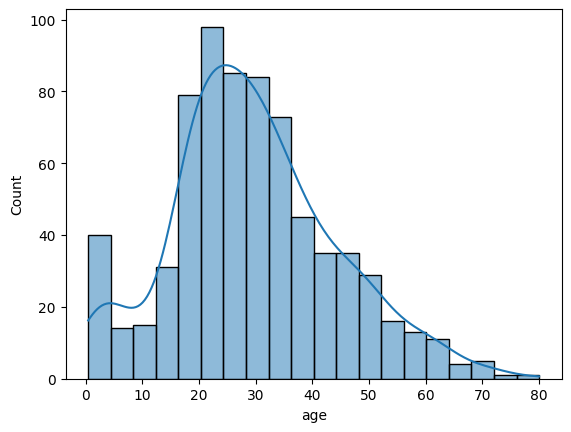

In [62]:
sns.histplot(df['age'], kde=True)
# sns.histplot(df['age'], kde=True) creates a histogram of the age column and overlays a smooth Kernel Density Estimation (KDE) curve to visualize the distribution of ages.

# We can see that it is almost normal distribution

In [63]:
# So can we replace the null value of age column with mean ?
df['Age_mean'] = df['age'].fillna(df['age'].mean())

# df['Age_mean'] = df['age'].fillna(df['age'].mean()) creates a new column Age_mean where all missing (NaN) values in the age column are replaced with the mean (average) age.

In [64]:
# Now compare the new Age_mean with the old age column

df[['Age_mean', 'age']]

# Clearly, the NaN is replaced with the mean

,Age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


In [65]:
# Mean imputation works well when we have normally distributed data

2. Median Value Imputation

In [66]:
# This is used when we have outliers in the dataset

df['age_median'] = df['age'].fillna(df['age'].median())

# df['age_median'] = df['age'].fillna(df['age'].median()) creates a new column age_median where all missing (NaN) values in the age column are replaced with the median (middle value) of the age column.

In [67]:
# Comparing the mean replacement, median and the original

df[['age_median', 'Age_mean', 'age']]

,age_median,Age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


3. Mode imputation technique

In [68]:
# Can be used with categorical values

# We first see which rows in the 'embarked' column has the NaN values

df[df['embarked'].isnull()] #Example of MCAR

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [69]:
# Let's also see which values are actually there in that column

df['embarked'].unique()

# It is 'S', 'C', 'Q', nan

array(['S', 'C', 'Q', nan], dtype=object)

In [70]:
# Can we see the not NaN value

df[df['embarked'].notna()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_mean,age_median
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.000000,22.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.000000,38.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.000000,26.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.000000,35.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.000000,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,27.000000,27.0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,19.000000,19.0
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,29.699118,28.0
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,26.000000,26.0


In [71]:
# Just see the embarked column

df[df['embarked'].notna()]['embarked'].mode()[0]

# df[df['embarked'].notna()]['embarked'].mode()[0] returns the most frequent (mode) value in the embarked column after excluding missing (NaN) values.

'S'

In [72]:
# Store this mode value

mode_value = df[df['embarked'].notna()]['embarked'].mode()[0]

In [73]:
df['embarked_mode'] = df['embarked'].fillna(mode_value)

# df['embarked_mode'] = df['embarked'].fillna(mode_value) creates a new column embarked_mode where all missing (NaN) values in the embarked column are replaced with the most frequent (mode) value stored in mode_value.

In [74]:
# Now see the new emabrked_mode column and embarked column side by side

df[['embarked_mode', 'embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [76]:
df['embarked_mode'].isnull().sum()

# Clearly 0 rows has NaN in embarked_mode column

np.int64(0)

In [78]:
# While the old embarked column
df['embarked'].isnull().sum()

#Clearly, it had 2 earlier

np.int64(2)